# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for Fine Tuning!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [1]:
# imports

import os
import re
# import math
import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
# import matplotlib.pyplot as plt
# import numpy as np
import pickle
# from collections import Counter
from openai import OpenAI
# from anthropic import Anthropic

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from items import Item
from testing import Tester

In [5]:
openai = OpenAI()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [8]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 200 examples (and 1 epoch)

fine_tune_train = train[:200]
fine_tune_validation = train[200:250]

# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [9]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [10]:
messages_for(train[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nBOX USA Jumbo Cable Ties, 175#, 60, Natural (Pack of 50)\n60 175# Jumbo Cable Ties - Natural. Nylon Cable Ties permanently secure cords, cables, bags, etc. Heavy-Duty ties for demanding applications! Nylon ties lock tight! - Will not slide or loosen. Nylon Cable Ties permanently secure cords, cables, bags, etc. Heavy-Duty ties for demanding applications! Nylon ties lock tight! - Will not slide or loosen. Country of origin China Material Nylon, Brand BOX USA, Dimensions LxWxH 60 x 0.35 inches, Closure Type Buckle, Pieces 50, model number Available April 21, 2016, Manufacturer BOX USA, Country of Origin China'},
 {'role': 'assistant', 'content': 'Price is $99.99'}]

In [11]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [12]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nBOX USA Jumbo Cable Ties, 175#, 60, Natural (Pack of 50)\n60 175# Jumbo Cable Ties - Natural. Nylon Cable Ties permanently secure cords, cables, bags, etc. Heavy-Duty ties for demanding applications! Nylon ties lock tight! - Will not slide or loosen. Nylon Cable Ties permanently secure cords, cables, bags, etc. Heavy-Duty ties for demanding applications! Nylon ties lock tight! - Will not slide or loosen. Country of origin China Material Nylon, Brand BOX USA, Dimensions LxWxH 60 x 0.35 inches, Closure Type Buckle, Pieces 50, model number Available April 21, 2016, Manufacturer BOX USA, Country of Origin China"}, {"role": "assistant", "content": "Price is $99.99"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "Ho

In [13]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [14]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [15]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [16]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
train_file

FileObject(id='file-VCYiCxEXXXF5yM2rYPWvSF', bytes=188989, created_at=1748346736, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [18]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [19]:
validation_file

FileObject(id='file-MdbpnD1Gj4JhNiUTBuvaRL', bytes=46319, created_at=1748346737, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [21]:
train_file.id

'file-VCYiCxEXXXF5yM2rYPWvSF'

## Step 2.1 Create or Reused Fine Tune Job in OpenAI 

In [26]:
jobs = openai.fine_tuning.jobs.list(limit=1).data # Get the first one

In [27]:
job_id1 = jobs[0].id
print(job_id1)
if jobs[0].status not in ["succeeded"]:
    print("Please wait until the job is created or completed...")

ftjob-UbF8ahxKeXYKLys9ROg3XFFi


## Step 2.2 Create a fine tune job, if Job ID1 == None

### Reused Fine Tune Model in OpenAI Fine Tune 

In [28]:
wandb_integration = {
    "type": "wandb", 
    "wandb": {"project": "gpt-pricer"}
}

In [29]:
if job_id1 == None:
    openai.fine_tuning.jobs.create(
        training_file=train_file.id,
        validation_file=validation_file.id,
        model="gpt-4o-mini-2024-07-18",
        seed=42,
        # hyperparameters={"n_epochs": 1},
        hyperparameters={"n_epochs": 3},
        integrations = [wandb_integration],
        suffix="pricer"
    )

    job_id1 = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [30]:
# job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
job_id = job_id1
job_id

'ftjob-UbF8ahxKeXYKLys9ROg3XFFi'

In [31]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-UbF8ahxKeXYKLys9ROg3XFFi', created_at=1748341420, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer:BbmFo14U', finished_at=1748343322, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=3), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-BHN9vcaLVFhVcD1D5ZK6Gq'], seed=42, status='succeeded', trained_tokens=294522, training_file='file-NzTETwuhFdT2sqTTeQhuV9', validation_file='file-5aFy2hwRd3ciyvatea1HLG', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-UbF8ahxKeXYKLys9ROg3XFFi'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_r

In [32]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-G2jgYE5uVkofnRZ8X8zZtQhk', created_at=1748344092, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-mwsyESN0n1qIvhohHMMEzQDX', created_at=1748344086, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-cAXFGMJFigLdEC8mJdBhL4QW', created_at=1748343324, level='info', message='Evaluating model against our usage policies before enabling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-3jSFLSoYUF8Xoow3UhN9N9N9', created_at=1748343324, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-FJjyCJCisIXU9w4hhpS67VLh', created_at=1748343324, level='info', message='Checkpoint created at step 1000', object=

# Step 3

Test our fine tuned model

In [33]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [34]:
fine_tuned_model_name

'ft:gpt-4o-mini-2024-07-18:personal:pricer:BbmFo14U'

In [35]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [36]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nLenovo ThinkVision 23.8 Full HD WLED LCD Monitor - 16 9 - Raven Black\nPower through your day on the ThinkVision Its FHD In-Plane Switching bezels helping you enhance efficiency. The TÜV Rheinland Eye Comfort certified ThinkVision is ideal for professionals as it minimizes eye fatigue and strain. Transfer or receive data with ease using varied options to connect other peripherals. This monitor is thoughtfully designed to keep your desk space organized and provide ergonomic benefits to users who spend long hours at work. Package Dimensions 18.592 cms (L) x 43.103 cms (W) x 18.592 cms (H) Package Quantity 1 Country Of Origin China Standing screen display size 23.8 Inches, Screen Resolution 192'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [37]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [38]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [39]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [40]:
print("Using model:", fine_tuned_model_name)


Using model: ft:gpt-4o-mini-2024-07-18:personal:pricer:BbmFo14U


In [41]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

249.0
159.99


In [42]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Lenovo ThinkVision 23.8 Full HD WLED LCD Monitor - 16 9 - Raven Black
Power through your day on the ThinkVision Its FHD In-Plane Switching bezels helping you enhance efficiency. The TÜV Rheinland Eye Comfort certified ThinkVision is ideal for professionals as it minimizes eye fatigue and strain. Transfer or receive data with ease using varied options to connect other peripherals. This monitor is thoughtfully designed to keep your desk space organized and provide ergonomic benefits to users who spend long hours at work. Package Dimensions 18.592 cms (L) x 43.103 cms (W) x 18.592 cms (H) Package Quantity 1 Country Of Origin China Standing screen display size 23.8 Inches, Screen Resolution 192

Price is $


Process status: 10% | Hits Rate so far: 84.0%
Process status: 20% | Hits Rate so far: 86.0%
Process status: 30% | Hits Rate so far: 82.7%
Process status: 40% | Hits Rate so far: 83.0%
Process status: 50% | Hits Rate so far: 83.2%
Process status: 60% | Hits Rate so far: 82.7%
Process status: 70% | Hits Rate so far: 84.0%
Process status: 80% | Hits Rate so far: 82.0%
Process status: 90% | Hits Rate so far: 83.6%
Process status: 100% | Hits Rate so far: 83.6%


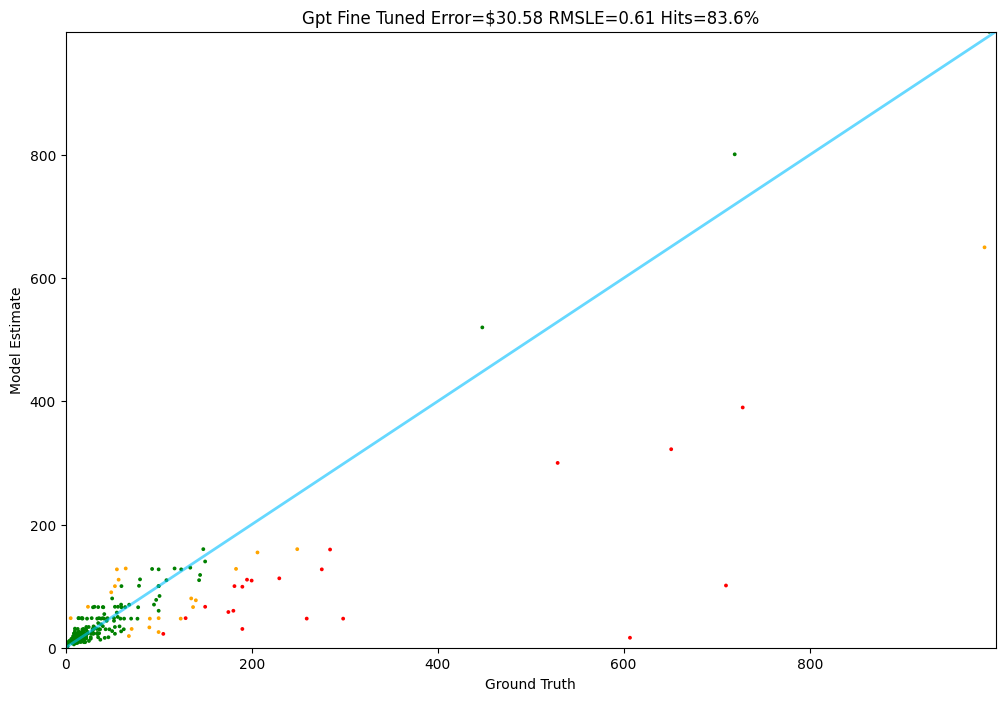

In [43]:
Tester.test(gpt_fine_tuned, test)